In [63]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
import re
import string
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report, ConfusionMatrixDisplay, roc_auc_score, roc_curve
import joblib

In [2]:
df = pd.read_csv('IMDB Dataset.csv')

In [3]:
df.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [4]:
df['sentiment'].value_counts()

sentiment
positive    25000
negative    25000
Name: count, dtype: int64

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   review     50000 non-null  object
 1   sentiment  50000 non-null  object
dtypes: object(2)
memory usage: 781.4+ KB


In [6]:
df.shape

(50000, 2)

In [7]:
df.isnull().sum()

review       0
sentiment    0
dtype: int64

In [8]:
df.duplicated().sum()

np.int64(418)

In [9]:
df.duplicated(subset=['review']).sum()

np.int64(418)

In [10]:
df = df.drop_duplicates(subset=['review']).reset_index(drop=True)

In [11]:
df.shape

(49582, 2)

In [12]:
df.duplicated(subset=['review']).sum()

np.int64(0)

In [13]:
df['sentiment'].value_counts()

sentiment
positive    24884
negative    24698
Name: count, dtype: int64

In [14]:
df['review'].str.len().describe()

count    49582.000000
mean      1310.568230
std        990.762238
min         32.000000
25%        699.000000
50%        971.000000
75%       1592.000000
max      13704.000000
Name: review, dtype: float64

In [15]:
df['sentiment'] = df['sentiment'].map({'positive':1, 'negative':0})

In [16]:
df.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,1
1,A wonderful little production. <br /><br />The...,1
2,I thought this was a wonderful way to spend ti...,1
3,Basically there's a family where a little boy ...,0
4,"Petter Mattei's ""Love in the Time of Money"" is...",1


In [17]:
df.shape

(49582, 2)

In [18]:
df['sentiment'].value_counts()

sentiment
1    24884
0    24698
Name: count, dtype: int64

In [19]:
df['review_length'] = df['review'].str.len()
df['review_length'].describe()

count    49582.000000
mean      1310.568230
std        990.762238
min         32.000000
25%        699.000000
50%        971.000000
75%       1592.000000
max      13704.000000
Name: review_length, dtype: float64

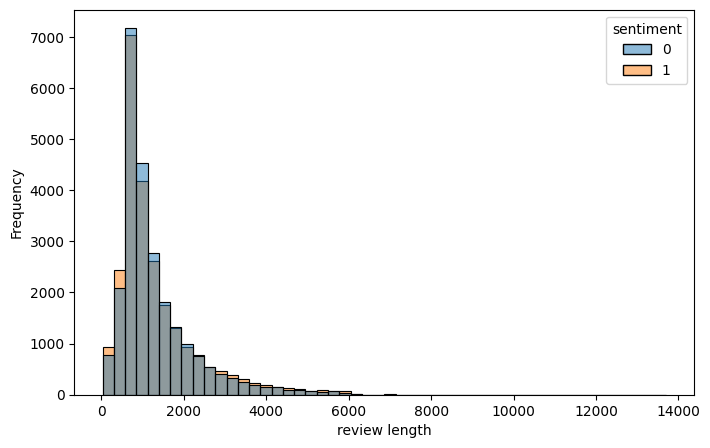

In [20]:
plt.figure(figsize=(8, 5))

sns.histplot(data=df, x='review_length', bins=50, hue='sentiment')
plt.xlabel('review length')
plt.ylabel('Frequency')
plt.show()

In [21]:
df.groupby('sentiment')['review_length'].agg(
    ['count', 'mean', 'median', 'min', 'max']
)

,count,mean,median,min,max
sentiment,,,,,
0,24698,1294.739615,974.0,32,8969
1,24884,1326.278532,969.0,65,13704


In [22]:
print(df[df['sentiment']==1]['review'].iloc[0])

One of the other reviewers has mentioned that after watching just 1 Oz episode you'll be hooked. They are right, as this is exactly what happened with me.<br /><br />The first thing that struck me about Oz was its brutality and unflinching scenes of violence, which set in right from the word GO. Trust me, this is not a show for the faint hearted or timid. This show pulls no punches with regards to drugs, sex or violence. Its is hardcore, in the classic use of the word.<br /><br />It is called OZ as that is the nickname given to the Oswald Maximum Security State Penitentary. It focuses mainly on Emerald City, an experimental section of the prison where all the cells have glass fronts and face inwards, so privacy is not high on the agenda. Em City is home to many..Aryans, Muslims, gangstas, Latinos, Christians, Italians, Irish and more....so scuffles, death stares, dodgy dealings and shady agreements are never far away.<br /><br />I would say the main appeal of the show is due to the fac

In [23]:
print(df[df['sentiment']==0]['review'].iloc[0])

Basically there's a family where a little boy (Jake) thinks there's a zombie in his closet & his parents are fighting all the time.<br /><br />This movie is slower than a soap opera... and suddenly, Jake decides to become Rambo and kill the zombie.<br /><br />OK, first of all when you're going to make a film you must Decide if its a thriller or a drama! As a drama the movie is watchable. Parents are divorcing & arguing like in real life. And then we have Jake with his closet which totally ruins all the film! I expected to see a BOOGEYMAN similar movie, and instead i watched a drama with some meaningless thriller spots.<br /><br />3 out of 10 just for the well playing parents & descent dialogs. As for the shots with Jake: just ignore them.


In [24]:
for i in range(3):
    print('Positive review:')
    print(df[df['sentiment']==1]['review'].iloc[i])
    print('\n'+'='*100+'\n')

Positive review:
One of the other reviewers has mentioned that after watching just 1 Oz episode you'll be hooked. They are right, as this is exactly what happened with me.<br /><br />The first thing that struck me about Oz was its brutality and unflinching scenes of violence, which set in right from the word GO. Trust me, this is not a show for the faint hearted or timid. This show pulls no punches with regards to drugs, sex or violence. Its is hardcore, in the classic use of the word.<br /><br />It is called OZ as that is the nickname given to the Oswald Maximum Security State Penitentary. It focuses mainly on Emerald City, an experimental section of the prison where all the cells have glass fronts and face inwards, so privacy is not high on the agenda. Em City is home to many..Aryans, Muslims, gangstas, Latinos, Christians, Italians, Irish and more....so scuffles, death stares, dodgy dealings and shady agreements are never far away.<br /><br />I would say the main appeal of the show 

In [25]:
for i in range(3):
    print('Negative review:')
    print(df[df['sentiment']==0]['review'].iloc[i])
    print('\n'+'='*100+'\n')

Negative review:
Basically there's a family where a little boy (Jake) thinks there's a zombie in his closet & his parents are fighting all the time.<br /><br />This movie is slower than a soap opera... and suddenly, Jake decides to become Rambo and kill the zombie.<br /><br />OK, first of all when you're going to make a film you must Decide if its a thriller or a drama! As a drama the movie is watchable. Parents are divorcing & arguing like in real life. And then we have Jake with his closet which totally ruins all the film! I expected to see a BOOGEYMAN similar movie, and instead i watched a drama with some meaningless thriller spots.<br /><br />3 out of 10 just for the well playing parents & descent dialogs. As for the shots with Jake: just ignore them.


Negative review:
This show was an amazing, fresh & innovative idea in the 70's when it first aired. The first 7 or 8 years were brilliant, but things dropped off after that. By 1990, the show was not really funny anymore, and it's c

In [26]:
df['review'].str.contains(r'<[^>]+>', regex=True).sum()

np.int64(28968)

In [27]:
def clean_text(text):
    text = text.lower()

    text = re.sub(r'<[^>]+>', '', text)
    text = re.sub(r"[^a-zA-Z\s']", '', text)
    text = re.sub(r'\s+', ' ', text).strip()

    return text

In [28]:
df['clean_review'] = df['review'].apply(clean_text)

In [29]:
df[['review', 'clean_review']].head()

,review,clean_review
0,One of the other reviewers has mentioned that ...,one of the other reviewers has mentioned that ...
1,A wonderful little production. <br /><br />The...,a wonderful little production the filming tech...
2,I thought this was a wonderful way to spend ti...,i thought this was a wonderful way to spend ti...
3,Basically there's a family where a little boy ...,basically there's a family where a little boy ...
4,"Petter Mattei's ""Love in the Time of Money"" is...",petter mattei's love in the time of money is a...


In [30]:
(df['clean_review'].str.len()==0).sum()

np.int64(0)

In [31]:
print(df['clean_review'].iloc[0])

one of the other reviewers has mentioned that after watching just oz episode you'll be hooked they are right as this is exactly what happened with methe first thing that struck me about oz was its brutality and unflinching scenes of violence which set in right from the word go trust me this is not a show for the faint hearted or timid this show pulls no punches with regards to drugs sex or violence its is hardcore in the classic use of the wordit is called oz as that is the nickname given to the oswald maximum security state penitentary it focuses mainly on emerald city an experimental section of the prison where all the cells have glass fronts and face inwards so privacy is not high on the agenda em city is home to manyaryans muslims gangstas latinos christians italians irish and moreso scuffles death stares dodgy dealings and shady agreements are never far awayi would say the main appeal of the show is due to the fact that it goes where other shows wouldn't dare forget pretty picture

In [32]:
X = df['clean_review']
y = df['sentiment']

In [33]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42, stratify=y)

In [34]:
print(len(X_train))
print(len(X_test))

39665
9917


In [35]:
tfidf = TfidfVectorizer(max_features=50000, ngram_range=(1,2), min_df=2, max_df=0.95, sublinear_tf=True)

In [36]:
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

In [37]:
print('Training TF-IDF shape: ',X_train_tfidf.shape)
print('Testing TF-IDF shape: ', X_test_tfidf.shape)

Training TF-IDF shape:  (39665, 50000)
Testing TF-IDF shape:  (9917, 50000)


In [38]:
print(tfidf.get_feature_names_out()[:20])

['aamir' 'aaron' 'ab' 'abandon' 'abandoned' 'abandons' 'abbey' 'abbot'
 'abbott' 'abbott and' 'abby' 'abc' 'abducted' 'abduction' 'abe' 'abel'
 'abigail' 'abilities' 'ability' 'ability of']


In [39]:
def evaluate_model(model, X_train, X_test, y_train, y_test, model_name):

    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    print('='*60)
    print(f'Model: {model_name}')
    print('-'*60)

    print(f'Accuracy: {accuracy:.4f}')
    print(f'Precision: {precision:.4f}')
    print(f'Recall: {recall:.4f}')
    print(f'F1_score: {f1:.4f}')

    print('\n Classification Report:')
    print(classification_report(
        y_test, y_pred,target_names=['Negative', 'Positive']
    ))

    cm = confusion_matrix(y_test, y_pred)
    print('Confusion Matrix')
    print(cm)

    ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Negative', 'Positive']).plot()
    plt.title(f'Confusion Matix - {model_name}')
    plt.show()

    return {
        'Model': model_name,
        'Accuracy' : accuracy,
        'Precision' : precision,
        'Recall' : recall,
        'F1_score' : f1,
        
    }

Model: Logistic Rregression
------------------------------------------------------------
Accuracy: 0.9036
Precision: 0.8926
Recall: 0.9184
F1_score: 0.9053

 Classification Report:
              precision    recall  f1-score   support

    Negative       0.92      0.89      0.90      4940
    Positive       0.89      0.92      0.91      4977

    accuracy                           0.90      9917
   macro avg       0.90      0.90      0.90      9917
weighted avg       0.90      0.90      0.90      9917

Confusion Matrix
[[4390  550]
 [ 406 4571]]


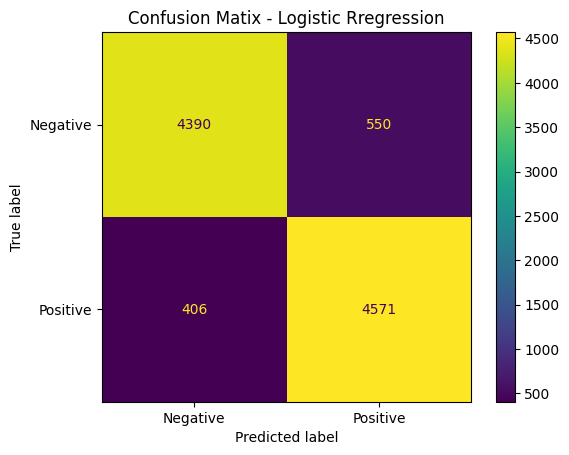

In [40]:
lr = LogisticRegression(max_iter=1000)
lr_result = evaluate_model(lr, X_train_tfidf, X_test_tfidf, y_train, y_test, 'Logistic Rregression')

Model: Multinomial Naive Bayes
------------------------------------------------------------
Accuracy: 0.8810
Precision: 0.8786
Recall: 0.8853
F1_score: 0.8819

 Classification Report:
              precision    recall  f1-score   support

    Negative       0.88      0.88      0.88      4940
    Positive       0.88      0.89      0.88      4977

    accuracy                           0.88      9917
   macro avg       0.88      0.88      0.88      9917
weighted avg       0.88      0.88      0.88      9917

Confusion Matrix
[[4331  609]
 [ 571 4406]]


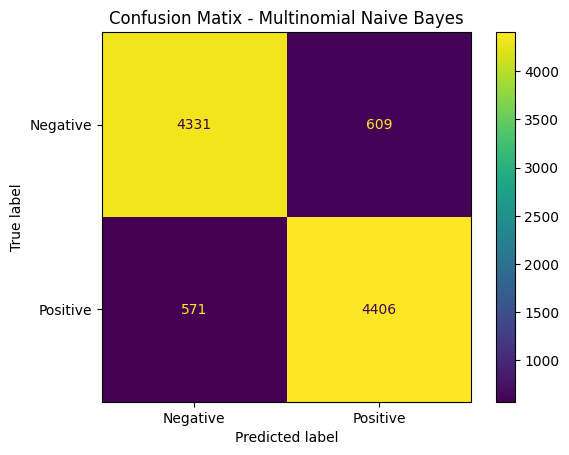

In [41]:
nb = MultinomialNB()
nb_result = evaluate_model(nb, X_train_tfidf, X_test_tfidf, y_train, y_test, 'Multinomial Naive Bayes')

Model: Linear SVM
------------------------------------------------------------
Accuracy: 0.9026
Precision: 0.8996
Recall: 0.9072
F1_score: 0.9034

 Classification Report:
              precision    recall  f1-score   support

    Negative       0.91      0.90      0.90      4940
    Positive       0.90      0.91      0.90      4977

    accuracy                           0.90      9917
   macro avg       0.90      0.90      0.90      9917
weighted avg       0.90      0.90      0.90      9917

Confusion Matrix
[[4436  504]
 [ 462 4515]]


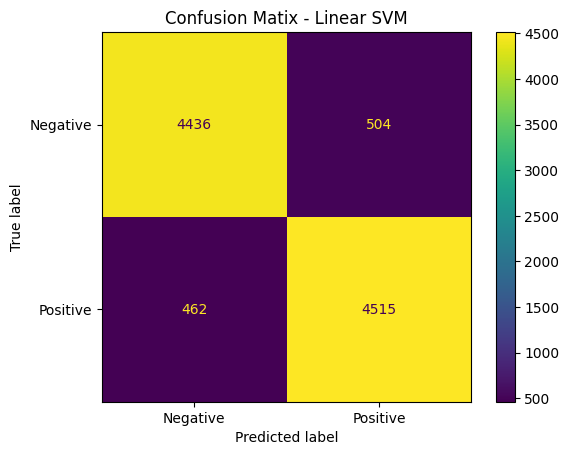

In [42]:
svm = LinearSVC(random_state=42)
svm_result = evaluate_model(svm, X_train_tfidf, X_test_tfidf, y_train, y_test, 'Linear SVM')

In [43]:
result = pd.DataFrame([
    lr_result,
    nb_result,
    svm_result
])

result.sort_values('F1_score', ascending=False)

,Model,Accuracy,Precision,Recall,F1_score
0,Logistic Rregression,0.903600,0.892599,0.918425,0.905328
2,Linear SVM,0.902592,0.899582,0.907173,0.903361
1,Multinomial Naive Bayes,0.881012,0.878564,0.885272,0.881906


In [44]:
lr = LogisticRegression(max_iter=1000, random_state=42)
param_grid_lr = {
    'C':[0.01,0.1,1,10,100],
    'solver':['liblinear', 'lbfgs']
}
grid_lr = GridSearchCV(
    estimator=lr,
    param_grid=param_grid_lr,
    cv=5,
    scoring='f1',
    n_jobs=-1,
    verbose=1
)

In [45]:
grid_lr.fit(X_train_tfidf, y_train)
print('Best Parameters:', grid_lr.best_params_)
print('Best CV F1:', grid_lr.best_score_)

Fitting 5 folds for each of 10 candidates, totalling 50 fits
Best Parameters: {'C': 10, 'solver': 'lbfgs'}
Best CV F1: 0.9086566243232307


Model: Tunned Logistic Rregression
------------------------------------------------------------
Accuracy: 0.9052
Precision: 0.8998
Recall: 0.9128
F1_score: 0.9062

 Classification Report:
              precision    recall  f1-score   support

    Negative       0.91      0.90      0.90      4940
    Positive       0.90      0.91      0.91      4977

    accuracy                           0.91      9917
   macro avg       0.91      0.91      0.91      9917
weighted avg       0.91      0.91      0.91      9917

Confusion Matrix
[[4434  506]
 [ 434 4543]]


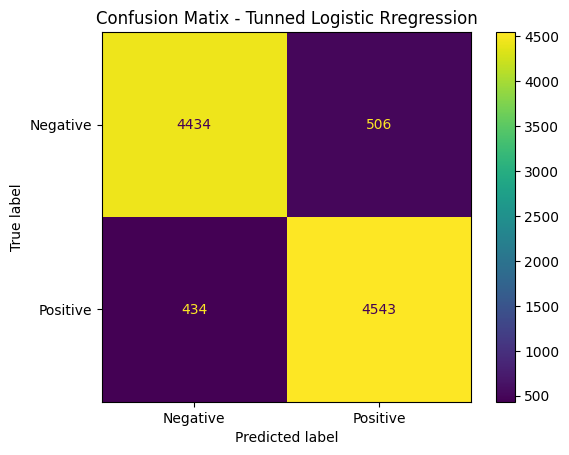

In [46]:
best_lr = grid_lr.best_estimator_
best_lr_result = evaluate_model(best_lr, X_train_tfidf, X_test_tfidf, y_train, y_test, 'Tunned Logistic Rregression')

In [47]:
svm = LinearSVC(random_state=42)

param_grid_svm = {
    'C':[0.01, 0.1, 1, 10, 100],
    'loss':['hinge', 'squared_hinge'],
    'class_weight':[None, 'balanced']
}

grid_svm = GridSearchCV(
    estimator=svm,
    param_grid=param_grid_svm,
    cv=5,
    scoring='f1',
    n_jobs=-1,
    verbose=1
)

In [48]:
grid_svm.fit(X_train_tfidf, y_train)
print('Best Parameters:', grid_svm.best_params_)
print('Best CV F1:', grid_svm.best_score_)

Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best Parameters: {'C': 1, 'class_weight': 'balanced', 'loss': 'hinge'}
Best CV F1: 0.9076036729078071


Model: Tunned Logistic SVM
------------------------------------------------------------
Accuracy: 0.9071
Precision: 0.9024
Recall: 0.9138
F1_score: 0.9081

 Classification Report:
              precision    recall  f1-score   support

    Negative       0.91      0.90      0.91      4940
    Positive       0.90      0.91      0.91      4977

    accuracy                           0.91      9917
   macro avg       0.91      0.91      0.91      9917
weighted avg       0.91      0.91      0.91      9917

Confusion Matrix
[[4448  492]
 [ 429 4548]]


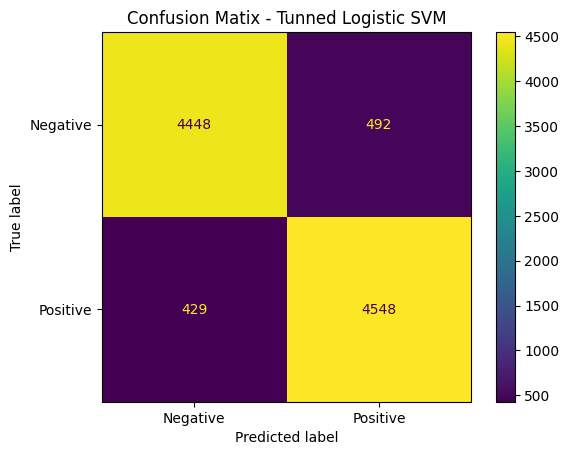

In [49]:
best_svm = grid_svm.best_estimator_
best_svm_result = evaluate_model(best_svm, X_train_tfidf, X_test_tfidf, y_train, y_test, 'Tunned Logistic SVM')

In [50]:
nb = MultinomialNB()

param_grid_nb = {
    'alpha':[0.01,0.05,0.1,0.5,1.0,2.0,5.0,10.0]
}

grid_nb = GridSearchCV(
    estimator=nb,
    param_grid=param_grid_nb,
    cv=5,
    scoring='f1',
    n_jobs=-1,
    verbose=1
)

In [51]:
grid_nb.fit(X_train_tfidf, y_train)
print('Best Parameters:', grid_nb.best_params_)
print('Best CV F1:', grid_nb.best_score_)

Fitting 5 folds for each of 8 candidates, totalling 40 fits
Best Parameters: {'alpha': 0.01}
Best CV F1: 0.8846632388280261


Model: Tunned Multinomial Naive Bayes
------------------------------------------------------------
Accuracy: 0.8829
Precision: 0.8774
Recall: 0.8913
F1_score: 0.8843

 Classification Report:
              precision    recall  f1-score   support

    Negative       0.89      0.87      0.88      4940
    Positive       0.88      0.89      0.88      4977

    accuracy                           0.88      9917
   macro avg       0.88      0.88      0.88      9917
weighted avg       0.88      0.88      0.88      9917

Confusion Matrix
[[4320  620]
 [ 541 4436]]


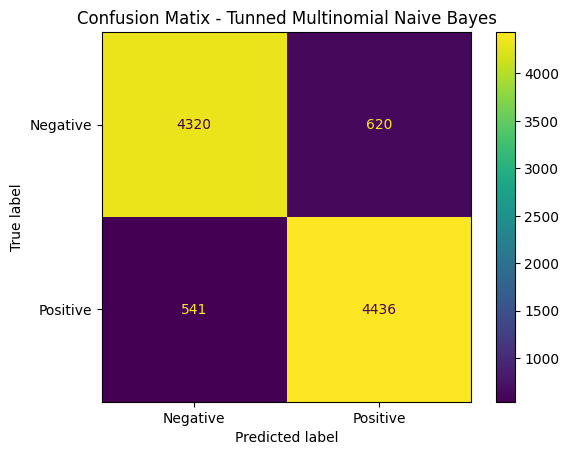

In [52]:
best_nb = grid_nb.best_estimator_
best_nb_result = evaluate_model(best_nb, X_train_tfidf, X_test_tfidf, y_train, y_test, 'Tunned Multinomial Naive Bayes')

In [53]:
tune_result = pd.DataFrame([
    best_lr_result,
    best_svm_result,
    best_nb_result
])

tune_result.sort_values('F1_score', ascending=False)

,Model,Accuracy,Precision,Recall,F1_score
1,Tunned Logistic SVM,0.907129,0.902381,0.913803,0.908056
0,Tunned Logistic Rregression,0.905213,0.899782,0.912799,0.906244
2,Tunned Multinomial Naive Bayes,0.882928,0.877373,0.891300,0.884282


In [54]:
final_model = best_svm
final_model.fit(X_train_tfidf, y_train)

y_pred_final = final_model.predict(X_test_tfidf)

print('Final Model: Tuned Linear SVM')
print('='*50)

print('Accuracy: ', accuracy_score(y_test, y_pred_final))
print('Precision: ', precision_score(y_test, y_pred_final))
print('Recall: ', recall_score(y_test, y_pred_final))
print('F1 Score: ', f1_score(y_test, y_pred_final))

print('\nclassification Report:')
print(classification_report(y_test, y_pred_final, target_names=['Negative', 'Positive']))

print('Confusion Matrix:')
print(confusion_matrix(y_test, y_pred_final))

Final Model: Tuned Linear SVM
Accuracy:  0.907129172128668
Precision:  0.9023809523809524
Recall:  0.9138034960819771
F1 Score:  0.9080563042827193

classification Report:
              precision    recall  f1-score   support

    Negative       0.91      0.90      0.91      4940
    Positive       0.90      0.91      0.91      4977

    accuracy                           0.91      9917
   macro avg       0.91      0.91      0.91      9917
weighted avg       0.91      0.91      0.91      9917

Confusion Matrix:
[[4448  492]
 [ 429 4548]]


In [55]:
error_df = pd.DataFrame({
    'review':X_test,
    'actual':y_test.values,
    'predicted':y_pred_final
})

errors = error_df[
    error_df['actual'] != error_df['predicted']
]

print('Total Misclassified: ', len(errors))

errors.head(10)

Total Misclassified:  921


,review,actual,predicted
34520,despite being a huge fan of fred astaire and g...,0,1
27110,well wellroeg touched a bit of a nerve there d...,1,0
33827,ok let me again admit that i haven't seen any ...,0,1
14394,i'm not here to tell you armored is kubrickian...,1,0
12423,this movie probably had a budget and still man...,1,0
31541,i was excited to hear that someone had made a ...,0,1
10328,using tons of stock footage not only from trad...,0,1
48081,in a poor village in mexico the colonel fernan...,1,0
22629,no one would ever question that director leos ...,1,0
29296,financially strapped paramount pulled out all ...,1,0


In [57]:
joblib.dump(final_model, "sentiment_svm.pkl")
joblib.dump(tfidf, "tfidf_vectorizer.pkl")

print("Model saved successfully!")
print("TF-IDF vectorizer saved successfully!")

Model saved successfully!
TF-IDF vectorizer saved successfully!


In [60]:
loaded_model = joblib.load("sentiment_svm.pkl")
loaded_tfidf = joblib.load("tfidf_vectorizer.pkl")

print("Model and vectorizer loaded successfully!")

Model and vectorizer loaded successfully!


In [61]:
def predict_sentiment(review):
    review = clean_text(review)

    review_tfidf = loaded_tfidf.transform([review])

    prediction = loaded_model.predict(review_tfidf)[0]

    if prediction == 1:
        return "Positive"
    else:
        return "Negative"

In [62]:
print(predict_sentiment(
    "This movie was absolutely fantastic. The acting was brilliant!"
))

print(predict_sentiment(
    "This was a terrible movie. I completely wasted my time."
))

Positive
Negative


In [64]:
y_scores = final_model.decision_function(X_test_tfidf)

# ROC-AUC
roc_auc = roc_auc_score(y_test, y_scores)

print(f"ROC-AUC Score: {roc_auc:.4f}")

ROC-AUC Score: 0.9683


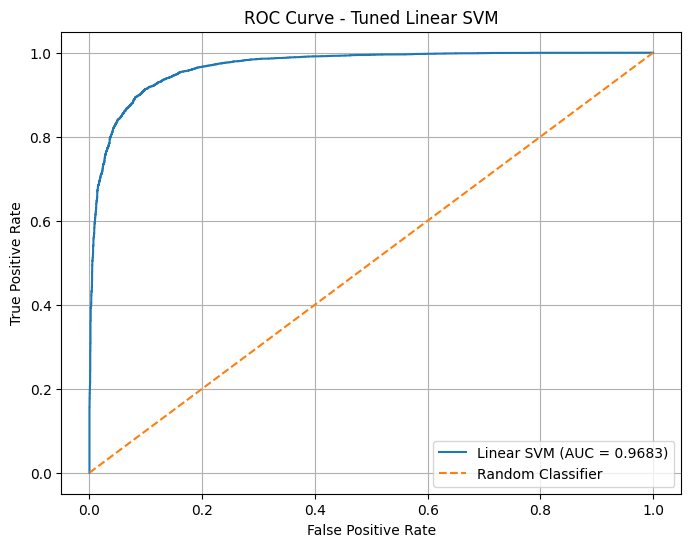

In [65]:
fpr, tpr, thresholds = roc_curve(y_test, y_scores)

plt.figure(figsize=(8, 6))

plt.plot(
    fpr,
    tpr,
    label=f"Linear SVM (AUC = {roc_auc:.4f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Tuned Linear SVM")
plt.legend()
plt.grid()
plt.show()